1. Importación de librerías y carga inicial

In [2]:
import os
import pandas as pd
import numpy as np

# Configurar rutas considerando que el notebook vive dentro de /notebooks
DATA_PATH = os.path.join("..", "data", "banking_conversations.csv")

if not os.path.exists(DATA_PATH):
    # Ruta alternativa por si el servidor ejecuta desde la raíz del proyecto
    DATA_PATH = os.path.join("data", "banking_conversations.csv")

print(f"Cargando dataset desde: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Inspección de los primeros 5 registros
df.head()

Cargando dataset desde: ..\data\banking_conversations.csv


,conversation_id,speaker,date_time,text
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:33+00:00,"Good morning, thank you for calling Union Fina..."
1,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help manag..."
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you wit..."
3,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:34:01.153846+00:00,Sure thing. My account number is 1234567890.
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:04.384615+00:00,"Thank, thank you for providing that informatio..."


2. Inspección de estructura, tipos de datos y nulos

In [3]:
print("=== Estructura del DataFrame ===")
print(f"Filas totales: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("=== Información de Columnas y Tipos de Datos ===")
df.info()

print("\n=== Conteo de Valores Nulos (NaN) ===")
print(df.isnull().sum())

=== Estructura del DataFrame ===
Filas totales: 5532112, Columnas: 4

=== Información de Columnas y Tipos de Datos ===
<class 'pandas.DataFrame'>
RangeIndex: 5532112 entries, 0 to 5532111
Data columns (total 4 columns):
 #   Column           Dtype
---  ------           -----
 0   conversation_id  str  
 1   speaker          str  
 2   date_time        str  
 3   text             str  
dtypes: str(4)
memory usage: 1.2 GB

=== Conteo de Valores Nulos (NaN) ===
conversation_id      0
speaker              0
date_time            0
text               630
dtype: int64


3. Sanitización y Limpieza de Datos (Data Cleaning)

In [ ]:
# Relleno de valores nulos
df["text"] = df["text"].fillna("").astype(str)
df["speaker"] = df["speaker"].fillna("desconocido").astype(str)
df["conversation_id"] = df["conversation_id"].astype(str)

# 2. Parseo correcto de la columna temporal
if "date_time" in df.columns:
    df["date_time"] = pd.to_datetime(df["date_time"], format="ISO8601", errors="coerce")

# Verificar que ya no existen nulos
print("=== Nulos tras la limpieza ===")
print(df.isnull().sum())

=== Nulos tras la limpieza ===
conversation_id          0
speaker                  0
date_time          5044147
text                     0
dtype: int64


4. Análisis Exploratorio de Datos (EDA)

In [5]:
# Métricas generales
total_turnos = len(df)
total_conversaciones = df["conversation_id"].nunique()
promedio_turnos = total_turnos / total_conversaciones

# Conteo de palabras por turno
df["word_count"] = df["text"].apply(lambda x: len(x.split()))
promedio_palabras = df["word_count"].mean()

print("=== MÉTRICAS DEL CORPUS BANCARIO ===")
print(f"• Total de turnos registradas: {total_turnos}")
print(f"• Diálogos únicos (conversation_id): {total_conversaciones}")
print(f"• Promedio de turnos por diálogo: {promedio_turnos:.2f}")
print(f"• Promedio de palabras por intervención: {promedio_palabras:.2f}")

print("\n=== Distribución por Emisor (Speaker) ===")
print(df["speaker"].value_counts())

=== MÉTRICAS DEL CORPUS BANCARIO ===
• Total de turnos registradas: 5532112
• Diálogos únicos (conversation_id): 301822
• Promedio de turnos por diálogo: 18.33
• Promedio de palabras por intervención: 22.23

=== Distribución por Emisor (Speaker) ===
speaker
agent     2880214
client    2651898
Name: count, dtype: int64


5. Agrupamiento e inspección de diálogos completos

In [6]:
# Agrupar por id de conversación
grouped = df.groupby("conversation_id")

# Tomar la primera conversación de muestra
sample_id = list(grouped.groups.keys())[0]
sample_conv = grouped.get_group(sample_id)

if "date_time" in sample_conv.columns and not sample_conv["date_time"].isnull().all():
    sample_conv = sample_conv.sort_values("date_time")

print(f"=== Muestra del Diálogo ID: {sample_id} ===")
for _, row in sample_conv.iterrows():
    print(f"[{row['speaker'].upper()}]: {row['text']}")

=== Muestra del Diálogo ID: 00001491bf0c4c19bd6f242933e35434 ===
[AGENT]: Good morning, thank you for holding Union Financial. My name is Adolfo, how may I assist you today?
[CLIENT]: Yeah, I need help with my stock trading account. I've been trying to get this issue resolved for weeks now and nobody has been able to help me.
[AGENT]: Sorry to hear that, Keshawn. Can you please provide me with your account number so I can look into this for you?
[CLIENT]: *sighs* Fine. It's 1234567890. But like I said, I've already called about this and nobody has been able to help me.
[AGENT]: I apologize for any inconvenience you've experienced, Keshawn. Let me see what's going on with your account. Can you tell me a little bit more about the issue you're having?
[CLIENT]: Look, I just want to be able to log in to my account. Every time I try, it says "invalid username or password." I've tried resetting my password multiple times, but nothing works. This is ridiculous.
[AGENT]: I understand how frust

6. Prueba de extracción heurística para perfiles de escenario

In [7]:
import re

scenarios_summary = []

for conv_id, group in grouped:
    # Obtener el texto completo
    transcript = " ".join(group["text"].tolist())
    client_turns = group[group["speaker"] == "client"]["text"].tolist()
    first_msg = client_turns[0] if client_turns else ""
    
    # Búsqueda de patrones
    name_match = re.search(r"my name is ([A-Za-z]+)", first_msg, re.IGNORECASE)
    acc_match = re.search(r"account number is (\d+)", transcript, re.IGNORECASE)
    
    scenarios_summary.append({
        "conversation_id": conv_id,
        "turns_count": len(group),
        "detected_name": name_match.group(1) if name_match else "N/A",
        "detected_account": acc_match.group(1) if acc_match else "N/A",
        "initial_request": first_msg[:60] + "..." if len(first_msg) > 60 else first_msg
    })

scenarios_df = pd.DataFrame(scenarios_summary)
scenarios_df.head(10)

,conversation_id,turns_count,detected_name,detected_account,initial_request
0,00001491bf0c4c19bd6f242933e35434,21,N/A,N/A,"Yeah, I need help with my stock trading accoun..."
1,00002670fe084aea855ef231e6aacca5,20,N/A,N/A,"Hi, I'm calling because I need to set up paren..."
2,0000316d4a7d40279611d40be8031a6a,13,Deena,1234567890,"Hi Alma, my name is Deena and my account numbe..."
3,000049eb72dd4ab6a1ee4b00983b306f,17,N/A,153216,"Yeah, I needm calling about my retirement acco..."
4,000053abe5674e569cbb91f618069ddc,15,Jude,1234567890,"Hi Daisy, my name is Jude. I'm calling because..."
5,00006a9936cf468fa700b2e3761a8cad,17,N/A,N/A,"Well, I've been trying to use mobile deposit f..."
6,000077a989dd430f8fcd93824f4d57d0,23,N/A,1234567890,"Hi Anna, I'm calling because set up financial ..."
7,0000a49be8704ec5b77470277592f52e,21,N/A,1234567890,"Hi, Jada. Yeah, I'm calling back because our c..."
8,0000faa37abf42e7909ad49996be7382,19,N/A,N/A,"Hi Ezra, I'm calling about my savings bond. I'..."
9,0000fede288a4e5bb53612de18fa2ab1,18,Brooke,N/A,"Hi Rory, my name is Brooke and I'm calling bec..."


In [8]:
# ¿El date_time nulo es "por conversación" o disperso dentro de cada una?
null_por_conv = df.groupby("conversation_id")["date_time"].apply(lambda x: x.isnull().mean())
print(null_por_conv.value_counts(bins=5))

(0.798, 0.997]        285889
(0.598, 0.798]         14534
(-0.001997, 0.199]      1042
(0.399, 0.598]           349
(0.199, 0.399]             8
Name: count, dtype: int64


In [9]:
acc_counts = scenarios_df["detected_account"].value_counts()
print(acc_counts.head(10))
print(f"% de conversaciones con el número de cuenta más repetido: {acc_counts.iloc[0]/len(scenarios_df)*100:.1f}%")

detected_account
N/A           195609
1234567890     97403
456789          2100
1234            1312
4234567890      1234
123456789        994
156789           378
9876543210       298
543210           180
54321             94
Name: count, dtype: int64
% de conversaciones con el número de cuenta más repetido: 64.8%


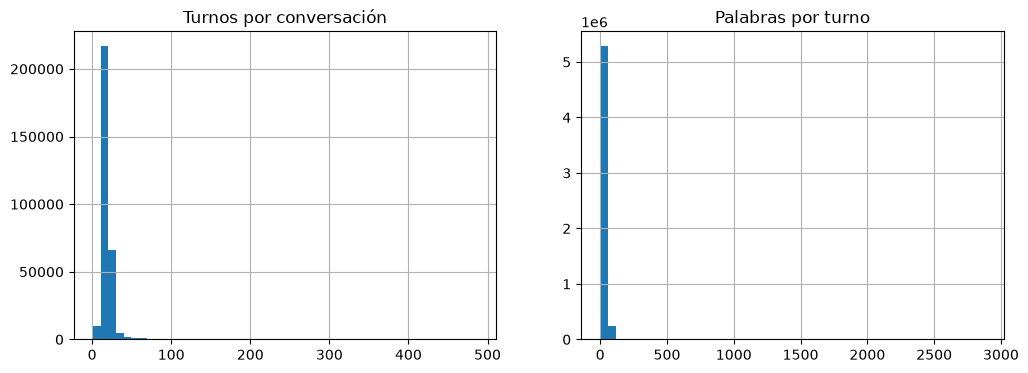

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("conversation_id").size().hist(bins=50, ax=axes[0])
axes[0].set_title("Turnos por conversación")

df["word_count"].hist(bins=50, ax=axes[1])
axes[1].set_title("Palabras por turno")
plt.show()

In [12]:
import re
mask = df["text"].str.contains(r"\*\w+\*", regex=True, na=False)
print(f"Turnos con acotaciones escénicas: {mask.sum()} ({mask.mean()*100:.2f}%)")
df.loc[mask, "text"].sample(10).tolist()

Turnos con acotaciones escénicas: 60700 (1.10%)


['*sighs* Fine. My account number is 1234567890. Now, can you just tell me how to buy these stupid stocks already?',
 "Thankright, I've located the charge. I apologm going to go ahead and reverse it for you. You should see the credit back in your account within the next 24 hours. IsDaphne: *sprised* Oh, okay. That was easy. Why couldn't the other person do that for me last week?",
 "*sighs* Alright, Thanks' that sounds okay.",
 "*sigh* No,I guess not. Fine. I'll find the documents and send them over.",
 "*sighs* Fine. I'm holding.",
 '*click*',
 "*sighs* Fine. It's 1234567890. Now, can you tell me what the status of my bond is?",
 "*sigh* Fine. It's 1234567890. Now, are you going to tell me what I want to know or do I need to keep waiting?",
 "*pauses* Um...I think't know. I don't have access to that information right now. Can we move on to the next question?",
 "*irritated* No, just get my claim processed already. That's all I want about."]

C:\Users\manci\AppData\Local\Temp\ipykernel_16296\3212691957.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_verification_turn"] = df["text"].str.contains(verif_pattern, case=False, regex=True, na=False)


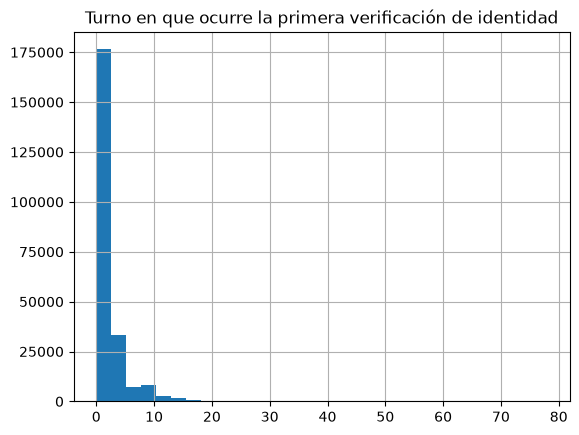

In [15]:
verif_pattern = r"(account number|social security number|verify your identity|date of birth)"
df["is_verification_turn"] = df["text"].str.contains(verif_pattern, case=False, regex=True, na=False)

# Posición del turno de verificación dentro de cada conversación
df["turn_index"] = df.groupby("conversation_id").cumcount()
verif_position = df[df["is_verification_turn"]].groupby("conversation_id")["turn_index"].min()

verif_position.hist(bins=30)
plt.title("Turno en que ocurre la primera verificación de identidad")
plt.show()